In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import pickle

In [2]:
df= pd.read_csv("demand_forecasting.csv")
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84


In [3]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

In [4]:
features=[
    "Price",
    "Discount",
    "Inventory Level",
    "Promotion",
    "Competitor Pricing",
    "Category"
    ]
features

['Price',
 'Discount',
 'Inventory Level',
 'Promotion',
 'Competitor Pricing',
 'Category']

In [5]:
target = "Demand"

In [6]:
x=df[features].copy()
y=df[target].copy()
x.head(),y.head()


(   Price  Discount  Inventory Level  Promotion  Competitor Pricing  \
 0  72.72         5              195          0               85.73   
 1  80.16        15              117          1               92.02   
 2  62.94        10              247          1               60.08   
 3  87.63        10              139          0               85.19   
 4  54.41         0              152          0               51.63   
 
       Category  
 0  Electronics  
 1     Clothing  
 2     Clothing  
 3  Electronics  
 4    Groceries  ,
 0    115
 1    229
 2    157
 3     52
 4     59
 Name: Demand, dtype: int64)

In [7]:
#Encoding from String to Machine usable form as Models dont take Strings
label_encoders ={}
categorical_cols =x.select_dtypes(include="object").columns
categorical_cols

Index(['Category'], dtype='object')

In [10]:
for col in categorical_cols:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col])
    label_encoders[col] = le
label_encoders

{'Category': LabelEncoder()}

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

In [ ]:
#In tree based algos, Scaling isnt required, 
# so we gon skip standard Scaler to keep pipeline simpler
#for TREE BASED MODELS(no scaling needed)- Decision Tree / Random Forest Classifier / Extra Trees Classifier / Regressor?? / 
# XGBoost / Lightboost / catboost --Not required

In [14]:
xgb = XGBRegressor(objective ="reg:squarederror" , n_jobs= -1)

In [15]:
param_grid={
    "n_estimators" :[200,300,500],
    "max_depth" :[3,4,6],
    "learning_rate" : [0.01,0.05,1],
    "subsample" : [0.7,0.8,1.0],
    "colsample_bytree" : [0.7,0.8,1.0],
    "min_child_weight" : [1,3,5]
}

In [16]:
random_search = RandomizedSearchCV(
    estimator = xgb,
    param_distributions=param_grid,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    n_jobs= -1
)

In [17]:
random_search.fit(x_train,y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategie

In [18]:
random_search.best_params_

{'subsample': 0.8,
 'n_estimators': 500,
 'min_child_weight': 5,
 'max_depth': 6,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

In [23]:
best_model = random_search.best_estimator_ 

In [26]:
y_pred = best_model.predict(x_test)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R2: {r2}")

RMSE: 35.45954760852939
MAE: 27.02826499938965
R2: 0.42523056268692017


In [36]:
best_model.feature_importances_

(array([0.08632138, 0.02871985, 0.02166681, 0.5956809 , 0.02834815,
        0.23926297], dtype=float32),
 ['Price',
  'Discount',
  'Inventory Level',
  'Promotion',
  'Competitor Pricing',
  'Category'])

<Axes: title={'center': 'Feature Importances'}>

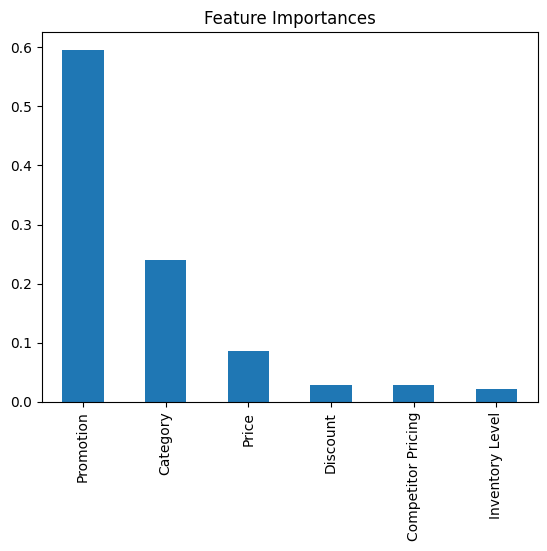

In [40]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index = x.columns
).sort_values(ascending=False)
feature_importance.plot(kind="bar",title="Feature Importances")

In [46]:
with open("label_encoders.pkl","wb") as f:
    pickle.dump(label_encoders,f)

In [47]:
with open("xgboost_demand_model.pkl","wb") as f:
    pickle.dump(best_model,f)